# **Imports and Loading Image**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


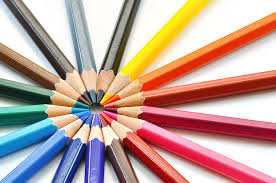

In [164]:
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow
from google.colab import drive
import matplotlib.pyplot as plt

drive.mount('/content/drive')
path = "/content/drive/MyDrive/IMG LABS/IMG ASSIGNMENTS/COLORMASKING/SUBMISSION/download.jpg"
original_img = cv.imread(path)
cv2_imshow(original_img)

# **Defining HSV Ranges for Color Red**

In [165]:
hsv_img = cv.cvtColor(original_img, cv.COLOR_BGR2HSV)
#cv2_imshow(hsv_img)
lower1 = np.array([0, 100, 100])
upper1= np.array([15, 255, 255])
lower2 = np.array([160, 50, 50])
upper2= np.array([180, 255, 255])

## **Initial Mask Before any Morphological Operations**

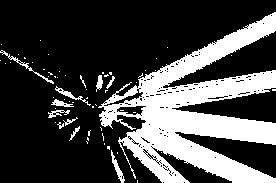

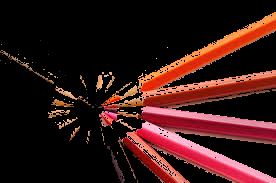

In [166]:
mask1 = cv.inRange(hsv_img, lower1, upper1)
mask2 = cv.inRange(hsv_img, lower2, upper2)
#we combine two masks using both ranges to capture red from both sides of the hue spectrum
mask = cv.bitwise_or(mask1, mask2)
masked_img = cv.bitwise_and(original_img, original_img, mask=mask)
cv2_imshow(mask)
cv2_imshow(masked_img)

# **Morphological Operations**

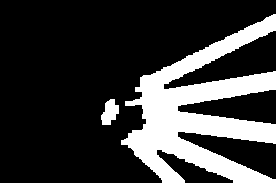

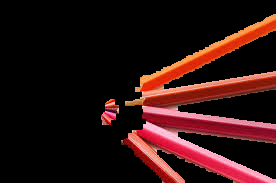

In [167]:
kernel = np.ones((3,3),np.uint8)

#trials
closing = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)
opening = cv.morphologyEx(closing, cv.MORPH_OPEN, kernel)
erosion2 = cv.erode(opening,kernel,iterations = 3)
dilation2 = cv.dilate(erosion2,kernel,iterations = 2)

cv2_imshow(dilation2)


masked_img_morphed = cv.bitwise_and(original_img, original_img, mask=dilation2)
cv2_imshow(masked_img_morphed)

